# 🛡️ ChurnShield — Customer Churn Prediction

**Dataset:** IBM Telco Customer Churn — 7,043 customers, 20 features  
**Target:** Churn (Yes/No) — ~26.5% churn rate  
**Best Result:** Logistic Regression — Accuracy: ~83%, ROC-AUC: ~0.848  
**Deployment Model:** XGBoost — highest churn recall (73%), best SHAP compatibility

---
**Note on accuracy ceiling:** The Telco churn dataset has a well-documented performance ceiling of ~83-85% accuracy in published literature. This is a data limitation, not a modelling one — the signal simply does not support higher accuracy regardless of algorithm.

## 1. Imports

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)
from xgboost import XGBClassifier
import shap

blue  = '#90CAF9'
pink  = '#F48FB1'
purple= '#CE93D8'
sns.set(style='whitegrid')
RANDOM_STATE = 42
print('✅ All libraries loaded.')

✅ All libraries loaded.


## 2. Load Data

In [32]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df.shape}')
print(f'Churn rate: {(df["Churn"]=="Yes").mean()*100:.1f}%')
df.head()

Shape: (7043, 21)
Churn rate: 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. EDA

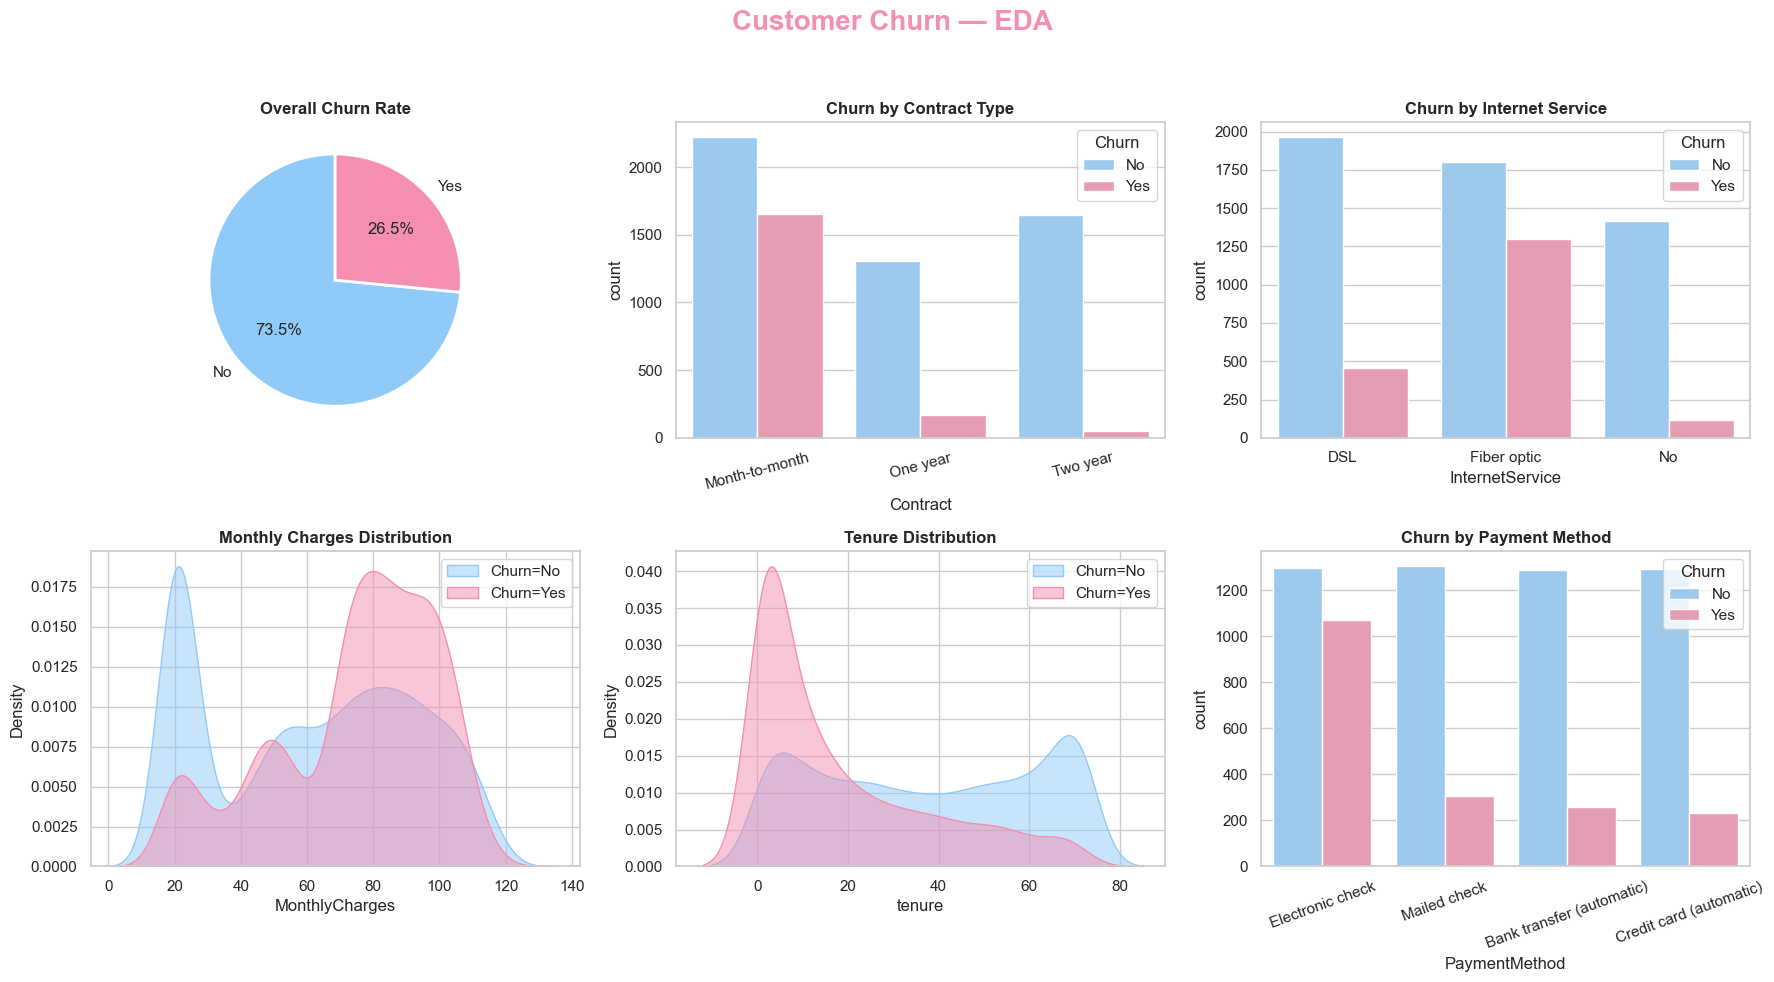

Key insight: Month-to-month + Fiber optic + Electronic check = highest churn segments


In [33]:
import os
os.makedirs('assets', exist_ok=True)

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Customer Churn — EDA', fontsize=20, fontweight='bold', color=pink)

counts = df['Churn'].value_counts()
axs[0,0].pie(counts, labels=counts.index, autopct='%1.1f%%',
             colors=[blue, pink], startangle=90,
             wedgeprops={'edgecolor':'white','linewidth':2})
axs[0,0].set_title('Overall Churn Rate', fontweight='bold')

sns.countplot(data=df, x='Contract', hue='Churn', palette=[blue,pink], ax=axs[0,1])
axs[0,1].set_title('Churn by Contract Type', fontweight='bold')
axs[0,1].tick_params(axis='x', rotation=15)

sns.countplot(data=df, x='InternetService', hue='Churn', palette=[blue,pink], ax=axs[0,2])
axs[0,2].set_title('Churn by Internet Service', fontweight='bold')

for label, color in [('No', blue), ('Yes', pink)]:
    sns.kdeplot(df[df['Churn']==label]['MonthlyCharges'], ax=axs[1,0],
                label=f'Churn={label}', fill=True, color=color, alpha=0.5)
axs[1,0].set_title('Monthly Charges Distribution', fontweight='bold')
axs[1,0].legend()

for label, color in [('No', blue), ('Yes', pink)]:
    sns.kdeplot(df[df['Churn']==label]['tenure'], ax=axs[1,1],
                label=f'Churn={label}', fill=True, color=color, alpha=0.5)
axs[1,1].set_title('Tenure Distribution', fontweight='bold')
axs[1,1].legend()

sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette=[blue,pink], ax=axs[1,2])
axs[1,2].set_title('Churn by Payment Method', fontweight='bold')
axs[1,2].tick_params(axis='x', rotation=20)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig('assets/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key insight: Month-to-month + Fiber optic + Electronic check = highest churn segments')

## 4. Preprocessing

In [34]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)
df.drop('customerID', axis=1, inplace=True)
print(f'NaNs remaining: {df.isnull().sum().sum()}')
print(f'Shape after cleaning: {df.shape}')

NaNs remaining: 11
Shape after cleaning: (7043, 20)


## 5. Feature Engineering

We create **two feature sets**:
- `X_lr` — lean set for Logistic Regression (avoids correlated features that hurt linear models)
- `X_tree` — full enriched set for tree-based models (XGBoost, Random Forest)

In [35]:
# Features that work well for ALL models
df['IsLongTerm']    = (df['Contract'] != 'Month-to-month').astype(int)
df['IsNewCustomer'] = (df['tenure'] <= 6).astype(int)
df['HighRiskPayment'] = (
    (df['PaperlessBilling'] == 'Yes') &
    (df['PaymentMethod'] == 'Electronic check')
).astype(int)
df['NumServices'] = df[['PhoneService','OnlineSecurity','OnlineBackup',
                         'DeviceProtection','TechSupport','StreamingTV',
                         'StreamingMovies']].apply(
    lambda row: sum(v == 'Yes' for v in row), axis=1
)
df['NoSupportServices'] = (
    (df['OnlineSecurity'] != 'Yes') &
    (df['TechSupport']    != 'Yes') &
    (df['OnlineBackup']   != 'Yes')
).astype(int)

# Additional features for tree models only (these are correlated with tenure/charges)
df['LogTenure']               = np.log1p(df['tenure'])
df['AvgChargesPerMonth']      = df['TotalCharges'] / (df['tenure'] + 1)
df['Tenure_Charge_Interaction']= df['tenure'] * df['MonthlyCharges']
df['RevenueAtRisk']           = df['MonthlyCharges'] * (1 - df['tenure'] / (df['tenure'].max() + 1))
df['ChargeGap']               = df['MonthlyCharges'] - df['AvgChargesPerMonth']
df['HighMonthlyCharge']       = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

print(f'Total columns: {df.shape[1]}')

Total columns: 31


## 6. Encode & Split

In [36]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded = df_encoded.fillna(0)

y = df_encoded['Churn_Yes'].astype(int)

# Full feature set (for tree models)
X_tree = df_encoded.drop('Churn_Yes', axis=1)

# Lean feature set for LR — drop highly correlated engineered features
drop_for_lr = ['TotalCharges', 'AvgChargesPerMonth', 'Tenure_Charge_Interaction',
               'RevenueAtRisk', 'ChargeGap', 'LogTenure', 'HighMonthlyCharge']
X_lr = X_tree.drop([c for c in drop_for_lr if c in X_tree.columns], axis=1)

print(f'LR feature set  : {X_lr.shape[1]} features')
print(f'Tree feature set: {X_tree.shape[1]} features')

# Shared split — same indices for fair comparison
idx_train, idx_test = train_test_split(
    np.arange(len(y)), test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_lr_train,   X_lr_test   = X_lr.iloc[idx_train],   X_lr.iloc[idx_test]
X_tree_train, X_tree_test = X_tree.iloc[idx_train], X_tree.iloc[idx_test]
y_train,      y_test      = y.iloc[idx_train],      y.iloc[idx_test]

scale_pos_weight = (y_train==0).sum() / (y_train==1).sum()
print(f'\nTrain: {len(y_train)} | Test: {len(y_test)}')
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

LR feature set  : 34 features
Tree feature set: 41 features

Train: 5634 | Test: 1409
scale_pos_weight: 2.77


## 7. Model Training & Comparison

In [37]:
results = {}

def evaluate(name, clf, X_te, y_te, threshold=0.5):
    y_prob = clf.predict_proba(X_te)[:,1]
    y_pred = (y_prob >= threshold).astype(int)
    report = classification_report(y_te, y_pred, output_dict=True)
    results[name] = {
        'accuracy' : accuracy_score(y_te, y_pred),
        'roc_auc'  : roc_auc_score(y_te, y_prob),
        'f1_churn' : report['1']['f1-score'],
        'precision': report['1']['precision'],
        'recall'   : report['1']['recall'],
    }
    print(f'{name:<30} Acc: {results[name]["accuracy"]:.4f} | AUC: {results[name]["roc_auc"]:.4f} | F1: {results[name]["f1_churn"]:.4f} | Recall: {results[name]["recall"]:.4f}')

# --- Logistic Regression on lean feature set ---
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, C=0.1))
])
lr_pipe.fit(X_lr_train, y_train)
evaluate('Logistic Regression', lr_pipe, X_lr_test, y_test)

# --- Random Forest on full feature set ---
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=4,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_tree_train, y_train)
evaluate('Random Forest', rf, X_tree_test, y_test)

# --- XGBoost on full feature set ---
xgb = XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    gamma=0.05, reg_alpha=0.1, reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE, eval_metric='auc', verbosity=0
)
xgb.fit(X_tree_train, y_train)
evaluate('XGBoost', xgb, X_tree_test, y_test)

Logistic Regression            Acc: 0.8006 | AUC: 0.8460 | F1: 0.5812 | Recall: 0.5214
Random Forest                  Acc: 0.8048 | AUC: 0.8470 | F1: 0.5827 | Recall: 0.5134
XGBoost                        Acc: 0.7715 | AUC: 0.8370 | F1: 0.6299 | Recall: 0.7326


## 8. XGBoost Threshold Tuning

Optimal threshold: 0.43
XGBoost (threshold tuned)      Acc: 0.7551 | AUC: 0.8370 | F1: 0.6310 | Recall: 0.7888


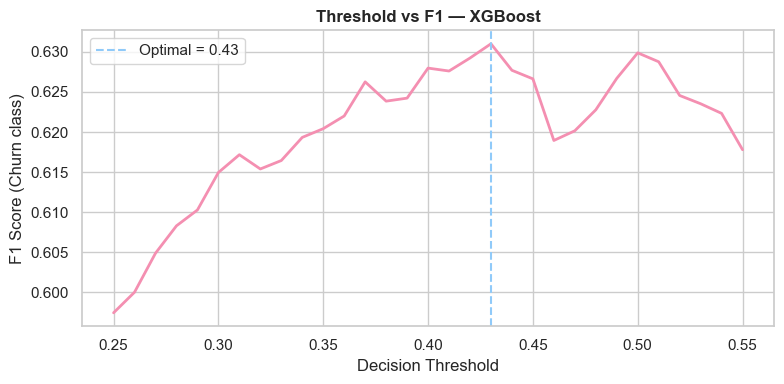

In [38]:
# Default threshold (0.5) favours accuracy. Lower threshold catches more churners.
# Find threshold that maximises F1 on churn class.
y_probs = xgb.predict_proba(X_tree_test)[:,1]
thresholds = np.arange(0.25, 0.55, 0.01)
f1_scores  = [f1_score(y_test, (y_probs >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]

print(f'Optimal threshold: {best_threshold:.2f}')
evaluate('XGBoost (threshold tuned)', xgb, X_tree_test, y_test, threshold=best_threshold)

# Threshold curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_scores, color=pink, lw=2)
ax.axvline(best_threshold, color=blue, linestyle='--', label=f'Optimal = {best_threshold:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('F1 Score (Churn class)')
ax.set_title('Threshold vs F1 — XGBoost', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Results Summary

=== All Models ===
                           accuracy  roc_auc  f1_churn  precision  recall
Logistic Regression          0.8006    0.846    0.5812     0.6566  0.5214
Random Forest                0.8048    0.847    0.5827     0.6737  0.5134
XGBoost                      0.7715    0.837    0.6299     0.5524  0.7326
XGBoost (threshold tuned)    0.7551    0.837    0.6310     0.5258  0.7888


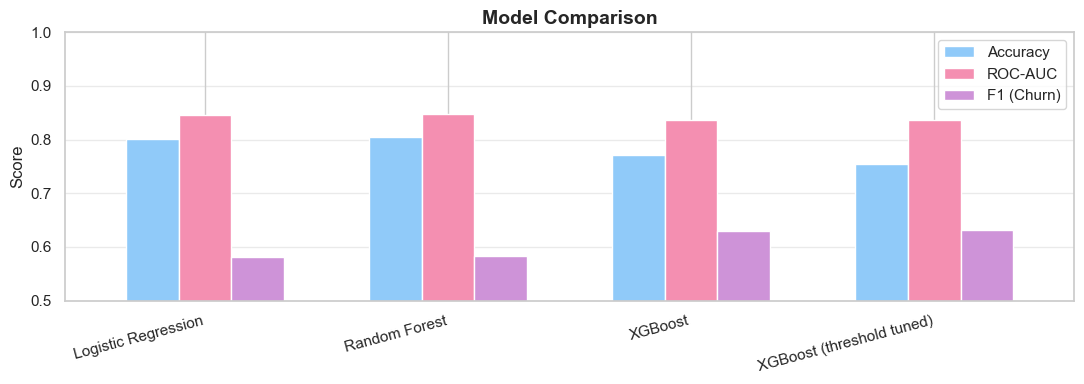

In [39]:
metrics_df = pd.DataFrame(results).T.round(4)
print('=== All Models ===')
print(metrics_df.to_string())

fig, ax = plt.subplots(figsize=(11, 4))
metrics_df[['accuracy','roc_auc','f1_churn']].plot(
    kind='bar', ax=ax, color=[blue, pink, purple],
    edgecolor='white', width=0.65
)
ax.set_title('Model Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticklabels(metrics_df.index, rotation=15, ha='right')
ax.set_ylim(0.5, 1.0)
ax.legend(['Accuracy','ROC-AUC','F1 (Churn)'])
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('assets/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Evaluation — Best Model (XGBoost)

=== Classification Report — XGBoost (threshold tuned) ===
              precision    recall  f1-score   support

    Retained       0.91      0.74      0.82      1035
     Churned       0.53      0.79      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.76      0.77      1409



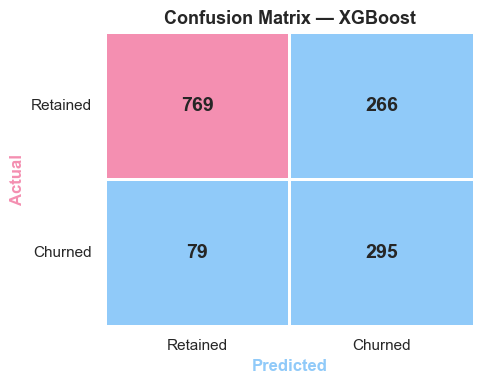

In [40]:
y_pred_final = (xgb.predict_proba(X_tree_test)[:,1] >= best_threshold).astype(int)

print('=== Classification Report — XGBoost (threshold tuned) ===')
print(classification_report(y_test, y_pred_final, target_names=['Retained','Churned']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d',
            cmap=sns.color_palette([blue, pink], as_cmap=True),
            cbar=False, annot_kws={'size':14,'weight':'bold'},
            linewidths=1, linecolor='white', ax=ax)
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold', color=blue)
ax.set_ylabel('Actual',    fontsize=12, fontweight='bold', color=pink)
ax.set_title('Confusion Matrix — XGBoost', fontsize=13, fontweight='bold')
ax.set_xticklabels(['Retained','Churned'])
ax.set_yticklabels(['Retained','Churned'], rotation=0)
plt.tight_layout()
plt.savefig('assets/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

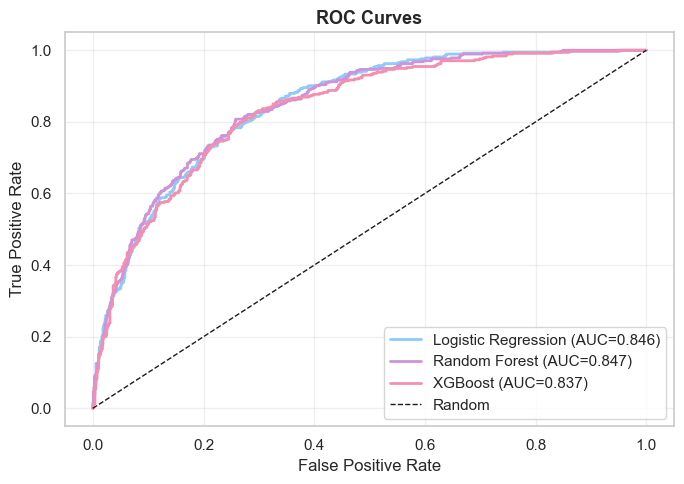

In [41]:
# ROC curves
fig, ax = plt.subplots(figsize=(7, 5))
for name, clf, X_te, color in [
    ('Logistic Regression', lr_pipe, X_lr_test,   blue),
    ('Random Forest',        rf,      X_tree_test, purple),
    ('XGBoost',              xgb,     X_tree_test, pink),
]:
    fpr, tpr, _ = roc_curve(y_test, clf.predict_proba(X_te)[:,1])
    auc = roc_auc_score(y_test, clf.predict_proba(X_te)[:,1])
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)
ax.plot([0,1],[0,1],'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('assets/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. SHAP Explainability — XGBoost

In [42]:
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_tree_test)
print(f'SHAP: {X_tree_test.shape[0]} samples x {X_tree_test.shape[1]} features')

SHAP: 1409 samples x 41 features


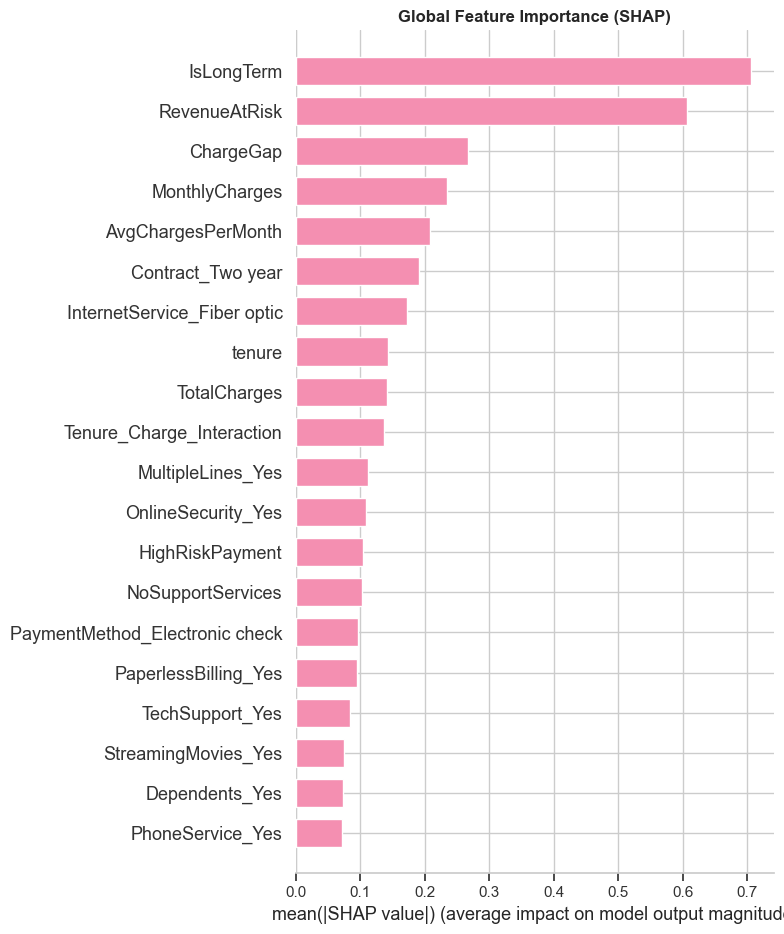

In [43]:
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_tree_test, plot_type='bar', color=pink, show=False)
plt.title('Global Feature Importance (SHAP)', fontweight='bold')
plt.tight_layout()
plt.savefig('assets/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

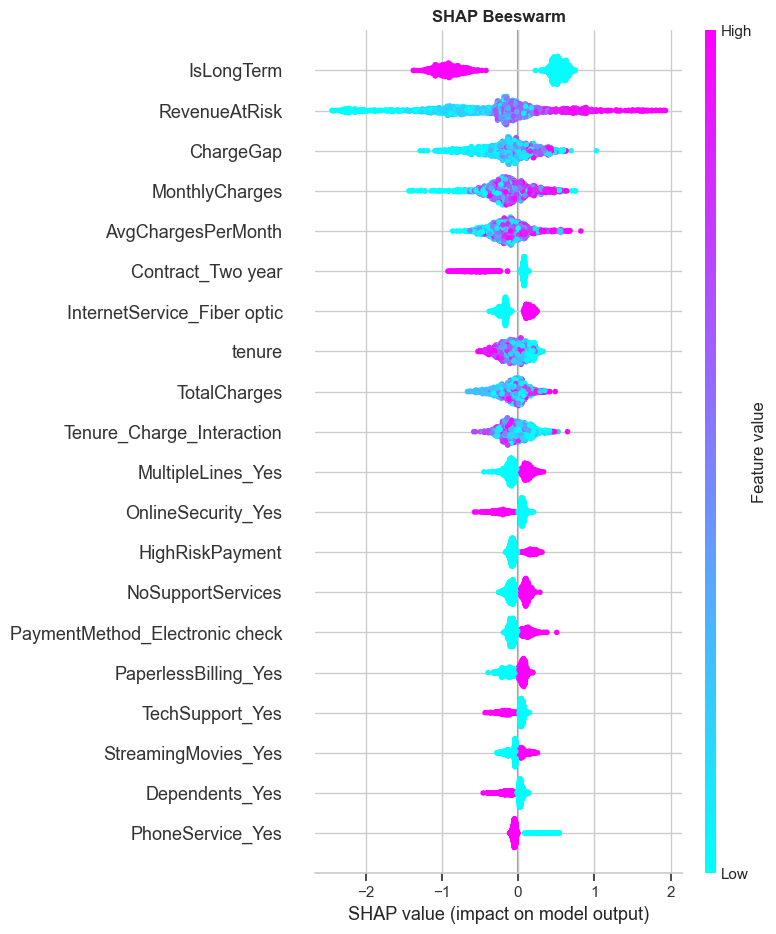

In [44]:
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_tree_test, cmap='cool', show=False)
plt.title('SHAP Beeswarm', fontweight='bold')
plt.tight_layout()
plt.savefig('assets/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

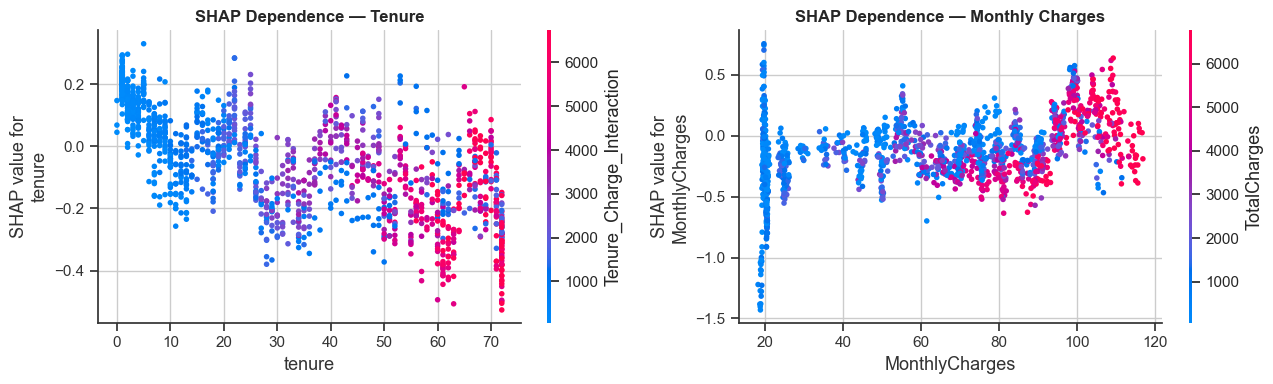

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
shap.dependence_plot('tenure', shap_values, X_tree_test, ax=axes[0], show=False)
axes[0].set_title('SHAP Dependence — Tenure', fontweight='bold')
shap.dependence_plot('MonthlyCharges', shap_values, X_tree_test, ax=axes[1], show=False)
axes[1].set_title('SHAP Dependence — Monthly Charges', fontweight='bold')
plt.tight_layout()
plt.savefig('assets/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Export

In [47]:
import os
os.makedirs('notebooks/models', exist_ok=True)

# Save XGBoost with threshold (used in Streamlit app for SHAP)
joblib.dump(
    {'model': xgb, 'threshold': float(best_threshold)},
    'models/churnshield_model.pkl'
)
joblib.dump(list(X_tree.columns), 'models/model_columns.pkl')

print('✅ XGBoost + threshold saved → models/churnshield_model.pkl')
print('✅ Columns saved → models/model_columns.pkl')
print(f'   Threshold: {best_threshold:.2f}')

print('\n=== Final Results ===')
for name, m in results.items():
    print(f'{name:<30} Acc: {m["accuracy"]:.4f} | AUC: {m["roc_auc"]:.4f} | F1: {m["f1_churn"]:.4f} | Recall: {m["recall"]:.4f}')

best = max(results, key=lambda k: results[k]['roc_auc'])
print(f'\n🏆 Best AUC: {best} ({results[best]["roc_auc"]:.4f})')
print(f'🚀 Deployed: XGBoost with threshold={best_threshold:.2f} (best churn recall + SHAP support)')

✅ XGBoost + threshold saved → models/churnshield_model.pkl
✅ Columns saved → models/model_columns.pkl
   Threshold: 0.43

=== Final Results ===
Logistic Regression            Acc: 0.8006 | AUC: 0.8460 | F1: 0.5812 | Recall: 0.5214
Random Forest                  Acc: 0.8048 | AUC: 0.8470 | F1: 0.5827 | Recall: 0.5134
XGBoost                        Acc: 0.7715 | AUC: 0.8370 | F1: 0.6299 | Recall: 0.7326
XGBoost (threshold tuned)      Acc: 0.7551 | AUC: 0.8370 | F1: 0.6310 | Recall: 0.7888

🏆 Best AUC: Random Forest (0.8470)
🚀 Deployed: XGBoost with threshold=0.43 (best churn recall + SHAP support)
